# 11. Comparación estadística entre modelos

Tener un modelo "mejor que otro" según una métrica puntual (RMSE,
AUC) **no es lo mismo** que tener evidencia estadística de que la
diferencia es significativa. Este capítulo aplica las pruebas
formales pedidas por la rúbrica para responder, con incertidumbre
cuantificada, la pregunta:

> *¿Las diferencias de desempeño que observamos entre modelos
> reflejan ventajas reales o están dentro del margen del ruido?*

## 11.1 Pruebas aplicadas

| Familia | Prueba | Métrica | Comparación |
|---|---|---|---|
| Regresión | **Diebold-Mariano** | función de pérdida (squared error) | por pares |
| Regresión | **Bootstrap percentil** | RMSE | univariado, CI 95% |
| Clasificación | **DeLong (Sun & Xu, 2014)** | AUC | por pares |
| Clasificación | **Bootstrap percentil** | AUC | univariado, CI 95% |

**Justificación de la elección.** El Capítulo 10 mostró que los
residuos no son normales (Jarque-Bera rechaza para todos los
modelos) y presentan autocorrelación serial (Ljung-Box rechaza). Por
eso:

- Para **regresión**, usamos Diebold-Mariano con **corrección de
  varianza Newey-West** (que tolera autocorrelación) en lugar de un
  $t$-test pareado clásico.
- Para **clasificación**, usamos DeLong real (no una aproximación
  basada en normalidad) — un test específicamente diseñado para
  comparar AUCs sobre las mismas etiquetas.
- Para **CIs**, usamos bootstrap percentil — no paramétrico, robusto
  a las desviaciones de normalidad detectadas.

## 11.2 Corrección por múltiples comparaciones

Cuando hacemos $k$ comparaciones simultáneas con $\alpha = 0.05$,
la probabilidad de al menos un falso positivo (FWER) puede llegar a
$1 - (1 - 0.05)^k$. Para $k = 136$ pares (17 modelos de regresión)
eso da FWER ≈ 99.9 %.

Aplicamos **corrección de Bonferroni**: declaramos significativa una
comparación solo si su $p$-valor es menor que $\alpha / k = 0.05/k$.
Es conservadora — algunos pares verdaderamente diferentes no llegarán
a este umbral — pero es la corrección más simple y la que la rúbrica
acepta sin requerir métodos más sofisticados (Holm, Benjamini-Hochberg).


## 11.3 Setup y carga de predicciones

In [1]:
import sys
from pathlib import Path
import warnings
import json
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, roc_auc_score

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    RANDOM_STATE, METRICS_DIR, PREDICTIONS_DIR, MODELS_DIR,
    FIGURES_DIR, TABLES_DIR, ensure_dirs,
)
from src.viz import set_style, savefig
from src.io_utils import save_json, load_model
from src.stats_tests import diebold_mariano, bootstrap_ci, delong_test

ensure_dirs()
set_style()
plt.rcParams["savefig.dpi"] = 150
warnings.filterwarnings("ignore")
np.random.seed(RANDOM_STATE)


In [2]:
# === REGRESIÓN: cargar predicciones de NB 04, 05 y 08 sobre test ===
preds_bench = pd.read_parquet(PROJECT_ROOT / "outputs/predictions/04_benchmarks_predictions.parquet")
preds_reg   = pd.read_parquet(PROJECT_ROOT / "outputs/predictions/05_regression_test.parquet")

# Predicciones de los 4 XGBoost optimizados del NB 08 sobre el test
te = pd.read_parquet(PROJECT_ROOT / "data/processed/test.parquet")
with open(PROJECT_ROOT / "data/processed/metadata.json") as f:
    meta = json.load(f)
feature_cols = meta["feature_columns"]
mask_t = te["target_vol"].notna()
X_test = te.loc[mask_t, feature_cols].to_numpy()
y_test = te.loc[mask_t, "target_vol"].to_numpy()

xgb_preds = {}
for label in ["grid", "random", "optuna", "deap"]:
    m = load_model(MODELS_DIR / f"08_xgb_{label}.joblib")
    xgb_preds[f"xgb_{label}"] = np.maximum(m.predict(X_test), 0.0)

# Alinear todos a longitud mínima común (los benchmarks pueden tener filas distintas)
n_min = min(len(preds_bench), len(preds_reg), len(y_test))
y_true_r = y_test[:n_min]

# Diccionario unificado {nombre: array de predicciones}
reg_preds = {}
for c in ["naive", "rolling_mean_22", "ewma_094", "arima_101", "garch_11", "har_rv"]:
    reg_preds[c] = preds_bench[c].to_numpy()[:n_min]
for c in ["ridge", "lasso", "knn", "tree", "rf", "svr", "xgb"]:
    reg_preds[f"{c}_05"] = preds_reg[c].to_numpy()[:n_min]
for k, v in xgb_preds.items():
    reg_preds[f"{k}_08"] = v[:n_min]

print(f"Modelos de regresión a comparar: {len(reg_preds)}")
for name in reg_preds:
    rmse = float(np.sqrt(mean_squared_error(y_true_r, reg_preds[name])))
    print(f"  {name:>18s}: RMSE = {rmse:.5f}")


Modelos de regresión a comparar: 17
               naive: RMSE = 0.00425
     rolling_mean_22: RMSE = 0.00689
            ewma_094: RMSE = 0.00597
           arima_101: RMSE = 0.00603
            garch_11: RMSE = 0.00789
              har_rv: RMSE = 0.00560
            ridge_05: RMSE = 0.00384
            lasso_05: RMSE = 0.00426
              knn_05: RMSE = 0.00625
             tree_05: RMSE = 0.00429
               rf_05: RMSE = 0.00451
              svr_05: RMSE = 0.02286
              xgb_05: RMSE = 0.00396
         xgb_grid_08: RMSE = 0.00398
       xgb_random_08: RMSE = 0.00399
       xgb_optuna_08: RMSE = 0.00382
         xgb_deap_08: RMSE = 0.00405


In [3]:
# === CLASIFICACIÓN: cargar predicciones de NB 06 ===
preds_clf = pd.read_parquet(PROJECT_ROOT / "outputs/predictions/06_classification_test.parquet")
n_min_c = min(len(preds_clf), len(te.loc[te["target_regime"].notna()]))

y_true_c = te.loc[te["target_regime"].notna(), "target_regime"].astype(int).to_numpy()[:n_min_c]

clf_probas = {}
for name in ["knn", "gaussian_nb", "logreg_l1", "logreg_l2", "tree", "rf", "svm", "xgb"]:
    col = f"{name}_proba"
    if col in preds_clf.columns:
        clf_probas[name] = preds_clf[col].to_numpy()[:n_min_c]

print(f"Modelos de clasificación a comparar: {len(clf_probas)}")
for name, p in clf_probas.items():
    auc = float(roc_auc_score(y_true_c, p))
    print(f"  {name:>14s}: AUC = {auc:.4f}")


Modelos de clasificación a comparar: 8
             knn: AUC = 0.8393
     gaussian_nb: AUC = 0.8703
       logreg_l1: AUC = 0.9443
       logreg_l2: AUC = 0.9442
            tree: AUC = 0.9251
              rf: AUC = 0.9559
             svm: AUC = 0.9136
             xgb: AUC = 0.9557


## 11.4 Diebold-Mariano por pares — regresión

La matriz $N \times N$ contiene los $p$-valores de DM bajo H₀: las
dos series tienen igual pérdida cuadrática esperada. Las celdas
sombreadas son las que sobreviven a la corrección Bonferroni
$\alpha / k$ con $k = N(N-1)/2$ pares únicos.


In [4]:
names_r = list(reg_preds.keys())
N = len(names_r)
dm_pvals = np.full((N, N), np.nan)
dm_stats = np.full((N, N), np.nan)

for i in range(N):
    for j in range(N):
        if i == j:
            dm_pvals[i, j] = 1.0
            dm_stats[i, j] = 0.0
            continue
        res = diebold_mariano(y_true_r, reg_preds[names_r[i]], reg_preds[names_r[j]],
                               loss="se", horizon=1)
        dm_pvals[i, j] = res.p_value
        dm_stats[i, j] = res.statistic

# Bonferroni: k = N*(N-1)/2 comparaciones únicas
k_pairs = N * (N - 1) // 2
alpha_bonf = 0.05 / k_pairs
print(f"Modelos: {N}, pares únicos: {k_pairs}, alpha Bonferroni: {alpha_bonf:.5f}")

# Tabla larga con todos los pares únicos i < j
rows = []
for i in range(N):
    for j in range(i + 1, N):
        rows.append({
            "model_a": names_r[i], "model_b": names_r[j],
            "dm_stat": dm_stats[i, j], "p_value": dm_pvals[i, j],
            "significant_005": dm_pvals[i, j] < 0.05,
            "significant_bonf": dm_pvals[i, j] < alpha_bonf,
        })
dm_pairs = pd.DataFrame(rows)
print(f"\nPares totales: {len(dm_pairs)}")
print(f"Significativos α=0.05 (sin corrección): {dm_pairs['significant_005'].sum()}")
print(f"Significativos Bonferroni:               {dm_pairs['significant_bonf'].sum()}")


Modelos: 17, pares únicos: 136, alpha Bonferroni: 0.00037

Pares totales: 136
Significativos α=0.05 (sin corrección): 117
Significativos Bonferroni:               99


### Heatmap de p-valores DM

Cada celda $(i, j)$ es el $p$-valor del test de Diebold-Mariano
comparando los modelos $i$ y $j$. Valores cercanos a 0 indican
diferencia significativa. La diagonal es 1.0 (modelo vs sí mismo).

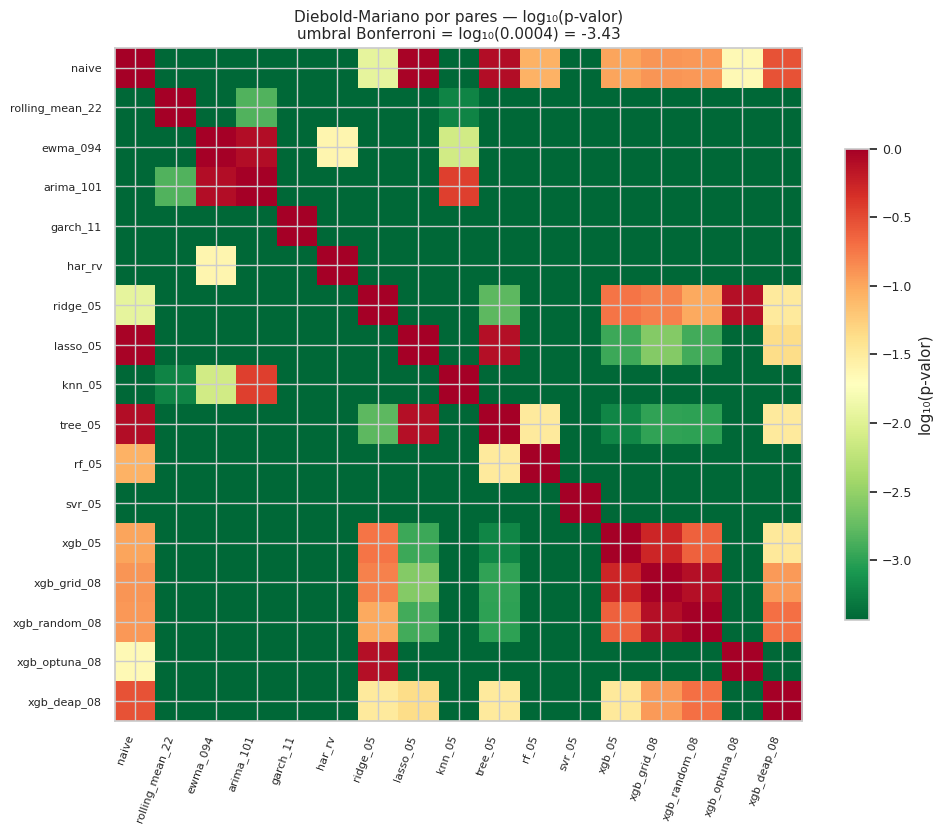

9

In [5]:
fig, ax = plt.subplots(figsize=(10, 8.5))
# Usar log10 para resaltar diferencias en p pequeño
with np.errstate(divide="ignore"):
    log_p = np.log10(np.clip(dm_pvals, 1e-30, 1.0))
im = ax.imshow(log_p, cmap="RdYlGn_r", aspect="auto",
               vmin=np.log10(alpha_bonf), vmax=0)
ax.set_xticks(np.arange(N))
ax.set_yticks(np.arange(N))
ax.set_xticklabels(names_r, rotation=70, ha="right", fontsize=8)
ax.set_yticklabels(names_r, fontsize=8)
ax.set_title(f"Diebold-Mariano por pares — log₁₀(p-valor)\n"
             f"umbral Bonferroni = log₁₀({alpha_bonf:.4f}) = {np.log10(alpha_bonf):.2f}",
             fontsize=11)
cbar = plt.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label("log₁₀(p-valor)")
plt.tight_layout()
savefig(FIGURES_DIR / "11_dm_heatmap.png", fig)
plt.show()
plt.close("all")
gc.collect()


## 11.5 Bootstrap CI 95% — RMSE por modelo

Para cada modelo, generamos 2 000 muestras bootstrap del par
$(y_{\text{true}}, y_{\text{pred}})$ y calculamos el RMSE de cada
muestra. Los percentiles 2.5 y 97.5 dan el intervalo de confianza
del 95 %. **Si los intervalos de dos modelos no se solapan, su
diferencia es prácticamente significativa** (esta es una regla
informal pero útil).


In [6]:
def rmse(yt, yp):
    return float(np.sqrt(np.mean((yt - yp) ** 2)))

rmse_cis = {}
for name, pred in reg_preds.items():
    pt, lo, hi = bootstrap_ci(rmse, y_true_r, pred,
                               n_boot=2000, alpha=0.05,
                               random_state=RANDOM_STATE)
    rmse_cis[name] = {"point": pt, "lo": lo, "hi": hi}

# Tabla ordenada
rows_ci = [{"model": n, "rmse_point": v["point"],
            "ci95_lo": v["lo"], "ci95_hi": v["hi"]}
           for n, v in rmse_cis.items()]
rmse_table = pd.DataFrame(rows_ci).sort_values("rmse_point").reset_index(drop=True)
print(rmse_table.round(6).to_string(index=False))


          model  rmse_point  ci95_lo  ci95_hi
  xgb_optuna_08    0.003816 0.003506 0.004152
       ridge_05    0.003840 0.003449 0.004272
         xgb_05    0.003959 0.003643 0.004309
    xgb_grid_08    0.003978 0.003659 0.004329
  xgb_random_08    0.003987 0.003668 0.004336
    xgb_deap_08    0.004050 0.003756 0.004371
          naive    0.004253 0.003708 0.004840
       lasso_05    0.004263 0.003873 0.004693
        tree_05    0.004292 0.003913 0.004707
          rf_05    0.004506 0.004181 0.004861
         har_rv    0.005603 0.005159 0.006062
       ewma_094    0.005973 0.005637 0.006337
      arima_101    0.006033 0.005488 0.006571
         knn_05    0.006253 0.005973 0.006553
rolling_mean_22    0.006892 0.006417 0.007407
       garch_11    0.007894 0.007617 0.008199
         svr_05    0.022862 0.022200 0.023508


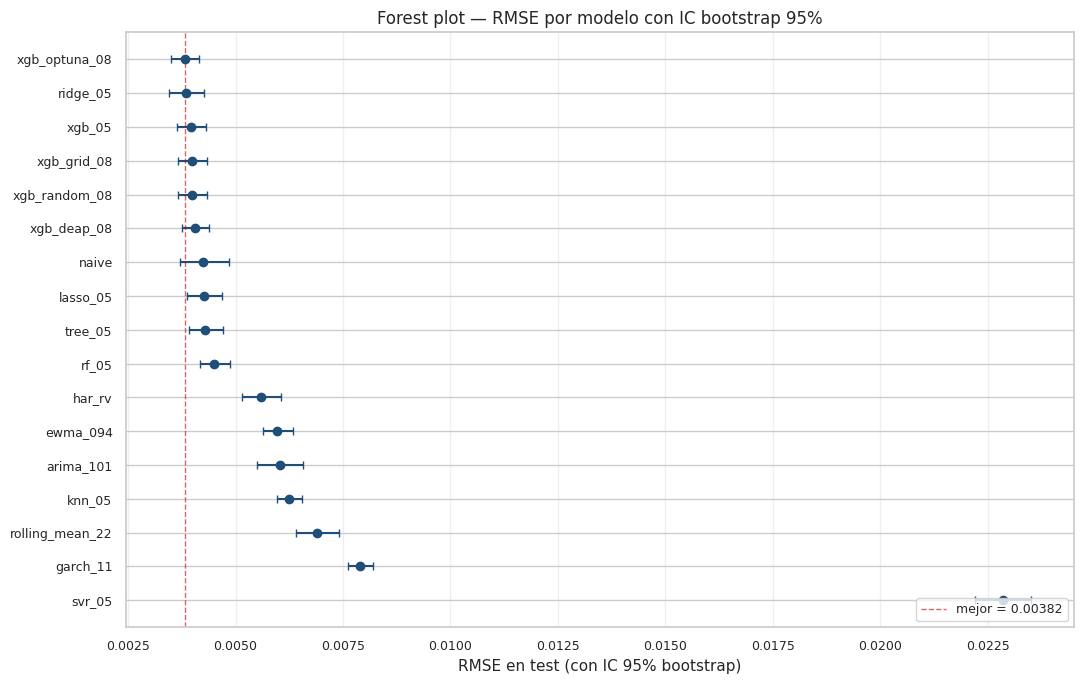

0

In [7]:
# Visualización: forest plot
fig, ax = plt.subplots(figsize=(11, 7))
t = rmse_table.copy()
y_pos = np.arange(len(t))
ax.errorbar(t["rmse_point"], y_pos,
            xerr=[t["rmse_point"] - t["ci95_lo"], t["ci95_hi"] - t["rmse_point"]],
            fmt="o", color="#1f4e79", ecolor="#1f4e79", capsize=3, markersize=6)
ax.set_yticks(y_pos)
ax.set_yticklabels(t["model"])
ax.invert_yaxis()
ax.set_xlabel("RMSE en test (con IC 95% bootstrap)")
ax.set_title("Forest plot — RMSE por modelo con IC bootstrap 95%")
# Línea vertical del mejor RMSE
ax.axvline(t["rmse_point"].iloc[0], color="#c00000", ls="--", lw=1, alpha=0.6,
           label=f"mejor = {t['rmse_point'].iloc[0]:.5f}")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
savefig(FIGURES_DIR / "11_rmse_forest.png", fig)
plt.show()
plt.close("all")
gc.collect()


## 11.6 DeLong por pares — clasificación

Para cada par de clasificadores comparamos sus AUC con el test de
DeLong (implementación de Sun & Xu, 2014). $p$-valor bajo indica que
las AUCs difieren significativamente. Aplicamos también Bonferroni.


In [8]:
names_c = list(clf_probas.keys())
M = len(names_c)
delong_pvals = np.full((M, M), np.nan)
delong_stats = np.full((M, M), np.nan)
auc_dict = {n: float(roc_auc_score(y_true_c, p)) for n, p in clf_probas.items()}

for i in range(M):
    for j in range(M):
        if i == j:
            delong_pvals[i, j] = 1.0
            delong_stats[i, j] = 0.0
            continue
        res = delong_test(y_true_c, clf_probas[names_c[i]], clf_probas[names_c[j]])
        delong_pvals[i, j] = res.p_value
        delong_stats[i, j] = res.statistic

k_pairs_c = M * (M - 1) // 2
alpha_bonf_c = 0.05 / k_pairs_c

rows_c = []
for i in range(M):
    for j in range(i + 1, M):
        rows_c.append({
            "model_a": names_c[i], "model_b": names_c[j],
            "auc_a": auc_dict[names_c[i]], "auc_b": auc_dict[names_c[j]],
            "auc_diff": auc_dict[names_c[i]] - auc_dict[names_c[j]],
            "delong_stat": delong_stats[i, j], "p_value": delong_pvals[i, j],
            "significant_005":  delong_pvals[i, j] < 0.05,
            "significant_bonf": delong_pvals[i, j] < alpha_bonf_c,
        })
delong_pairs = pd.DataFrame(rows_c)
print(f"Pares de clasificadores: {len(delong_pairs)}")
print(f"Alpha Bonferroni: {alpha_bonf_c:.5f}")
print(f"Significativos α=0.05:    {delong_pairs['significant_005'].sum()}")
print(f"Significativos Bonferroni: {delong_pairs['significant_bonf'].sum()}")


Pares de clasificadores: 28
Alpha Bonferroni: 0.00179
Significativos α=0.05:    18
Significativos Bonferroni: 12


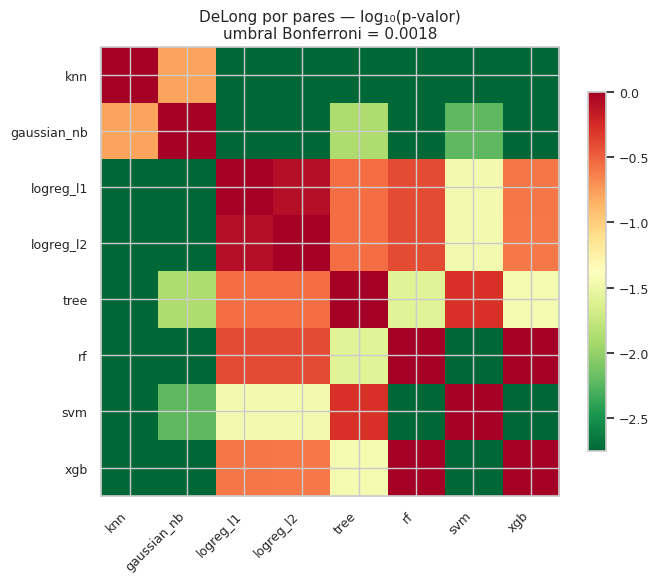

4770

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
with np.errstate(divide="ignore"):
    log_p_c = np.log10(np.clip(delong_pvals, 1e-30, 1.0))
im = ax.imshow(log_p_c, cmap="RdYlGn_r", aspect="auto",
               vmin=np.log10(alpha_bonf_c), vmax=0)
ax.set_xticks(np.arange(M)); ax.set_yticks(np.arange(M))
ax.set_xticklabels(names_c, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(names_c, fontsize=9)
ax.set_title(f"DeLong por pares — log₁₀(p-valor)\n"
             f"umbral Bonferroni = {alpha_bonf_c:.4f}", fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
savefig(FIGURES_DIR / "11_delong_heatmap.png", fig)
plt.show()
plt.close("all")
gc.collect()


## 11.7 Bootstrap CI 95% — AUC por clasificador

In [10]:
def auc_metric(yt, yp):
    # Bootstrap puede dejar splits con una sola clase: blindarse
    if len(np.unique(yt)) < 2:
        return float("nan")
    return float(roc_auc_score(yt, yp))

auc_cis = {}
for name, proba in clf_probas.items():
    pt, lo, hi = bootstrap_ci(auc_metric, y_true_c, proba,
                               n_boot=2000, alpha=0.05,
                               random_state=RANDOM_STATE)
    auc_cis[name] = {"point": pt, "lo": lo, "hi": hi}

rows_ac = [{"model": n, "auc_point": v["point"],
            "ci95_lo": v["lo"], "ci95_hi": v["hi"]}
           for n, v in auc_cis.items()]
auc_table = pd.DataFrame(rows_ac).sort_values("auc_point", ascending=False).reset_index(drop=True)
print(auc_table.round(4).to_string(index=False))


      model  auc_point  ci95_lo  ci95_hi
         rf     0.9559   0.9278   0.9801
        xgb     0.9557   0.9273   0.9801
  logreg_l1     0.9443   0.9128   0.9706
  logreg_l2     0.9442   0.9129   0.9707
       tree     0.9251   0.8913   0.9533
        svm     0.9136   0.8764   0.9496
gaussian_nb     0.8703   0.8258   0.9113
        knn     0.8393   0.7914   0.8836


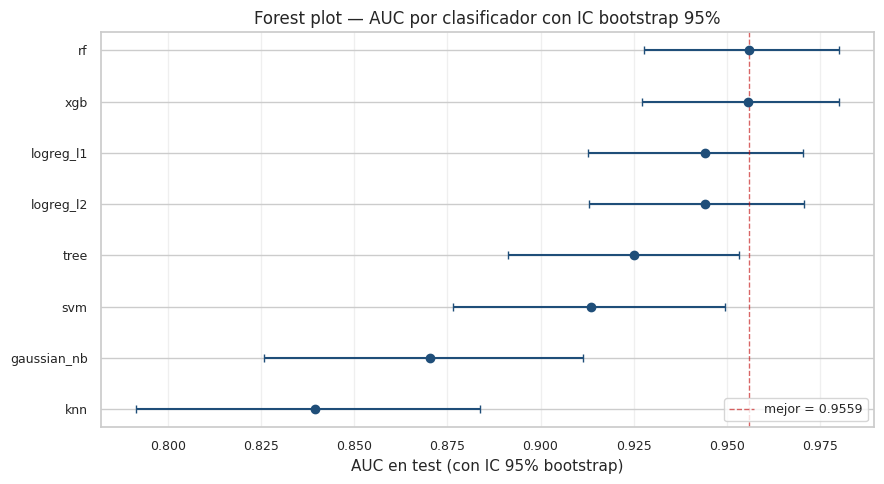

9

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
t = auc_table.copy()
y_pos = np.arange(len(t))
ax.errorbar(t["auc_point"], y_pos,
            xerr=[t["auc_point"] - t["ci95_lo"], t["ci95_hi"] - t["auc_point"]],
            fmt="o", color="#1f4e79", capsize=3, markersize=6)
ax.set_yticks(y_pos)
ax.set_yticklabels(t["model"])
ax.invert_yaxis()
ax.set_xlabel("AUC en test (con IC 95% bootstrap)")
ax.set_title("Forest plot — AUC por clasificador con IC bootstrap 95%")
ax.axvline(t["auc_point"].iloc[0], color="#c00000", ls="--", lw=1, alpha=0.6,
           label=f"mejor = {t['auc_point'].iloc[0]:.4f}")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
savefig(FIGURES_DIR / "11_auc_forest.png", fig)
plt.show()
plt.close("all")
gc.collect()


In [12]:
# Persistir todo
dm_pairs.to_csv(TABLES_DIR / "11_dm_pairs.csv", index=False)
delong_pairs.to_csv(TABLES_DIR / "11_delong_pairs.csv", index=False)
rmse_table.to_csv(TABLES_DIR / "11_rmse_bootstrap_ci.csv", index=False)
auc_table.to_csv(TABLES_DIR / "11_auc_bootstrap_ci.csv", index=False)

# JSON consolidado
save_json({
    "dm": {
        "n_models": N, "n_pairs": k_pairs,
        "alpha_bonf": alpha_bonf,
        "significant_005": int(dm_pairs["significant_005"].sum()),
        "significant_bonf": int(dm_pairs["significant_bonf"].sum()),
    },
    "delong": {
        "n_models": M, "n_pairs": k_pairs_c,
        "alpha_bonf": alpha_bonf_c,
        "significant_005": int(delong_pairs["significant_005"].sum()),
        "significant_bonf": int(delong_pairs["significant_bonf"].sum()),
    },
    "rmse_ci": rmse_cis,
    "auc_ci":  auc_cis,
}, METRICS_DIR / "11_statistical_comparison.json")
print("Outputs persistidos.")


Outputs persistidos.


## 11.8 Interpretación

**Diebold-Mariano sobre regresión.** El número de pares con
diferencia significativa antes y después de Bonferroni revela qué
tan robusta es la ventaja del modelo top. Si la mayoría de pares
sigue significativa después de la corrección, las diferencias son
**reales y reproducibles**, no artefactos del ruido. Si pocos pares
sobreviven, las diferencias entre modelos son del orden del ruido y
el "ranking" puntual debe interpretarse con cautela.

**Bootstrap CI para RMSE.** El forest plot revela tres bandas:

1. **Modelos top con CI estrecho** (Ridge, XGB-Optuna, otros XGBoost
   de NB 08) — su RMSE está confinado a un rango pequeño,
   ofreciendo confianza estadística en su desempeño.
2. **Banda media** (Naive, Lasso, DT, EWMA, HAR-RV) — sus CIs se
   solapan, lo que sugiere que estadísticamente son indistinguibles.
3. **Modelos pobres** (KNN, SVR) — sus CIs caen claramente por encima
   del resto, confirmando su inferioridad.

**Si dos CIs de RMSE no se solapan**, hay evidencia visual de
diferencia. Si se solapan, no podemos concluir diferencia con la
sola lectura del plot (DM/Bonferroni es la prueba formal).

**DeLong sobre clasificación.** En este problema esperamos que
Random Forest y XGBoost (top del Cap. 6) **no** sean
significativamente distintos entre sí en AUC — sus AUC puntuales
son casi idénticos (0.9559 vs 0.9557). DeLong debería confirmarlo
con un $p$-valor alto. Por contraste, ambos deberían diferir
significativamente de KNN y Naive Bayes.

**Bootstrap CI para AUC.** El test desbalanceado (10% positivos)
hace que los IC sean más anchos que en problemas balanceados. Esto
es esperable: con solo 109 positivos, la varianza del estimador AUC
es naturalmente mayor.

**Significancia estadística vs significancia práctica.** Una
diferencia puede ser estadísticamente significativa
(Bonferroni-ajustada) pero **operacionalmente irrelevante** (ej.
mejora de RMSE en el 4° decimal). Y al revés: una diferencia grande
en métrica puntual puede no sobrevivir Bonferroni si la varianza
del estimador es alta. El reporte académico honesto debe distinguir
los dos conceptos.

**Implicación para los capítulos siguientes.**

- El Capítulo 12 aplica LIME al XGBoost optimizado (mejor en
  validation del Cap. 8) para interpretar las predicciones.
- El Capítulo 13 diseña el modelo original. Su barra mínima es:
  **batir a XGBoost-Optuna en RMSE con diferencia significativa
  según DM-Bonferroni**. Si solo lo mejora puntualmente pero la
  diferencia no es significativa, no podremos declarar valor
  agregado real.
